# BAB 3 — DIMENSIONALITY REDUCTION

## 3.1 Pengenalan Dimensionality Reduction

Dimensionality Reduction adalah teknik untuk mengurangi jumlah fitur pada dataset.

Contohnya, dataset memiliki 100 fitur kemudian dikurangi menjadi 10 fitur.

Tujuan dimensionality reduction antara lain:
- Mengurangi kompleksitas data
- Mempercepat proses Machine Learning
- Mengurangi noise
- Mempermudah visualisasi
- Mengurangi jumlah fitur yang digunakan

Beberapa metode yang akan digunakan:
- PCA
- LDA
- t-SNE
- Variance Threshold
- SelectKBest

## 3.2 Dataset Iris

Dataset Iris merupakan dataset yang sering digunakan sebagai contoh dalam Machine Learning.

Dataset ini memiliki 150 data dan 4 fitur.

Fitur tersebut menggambarkan karakteristik bunga Iris.

In [1]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

print("Ukuran data:", X.shape)

Ukuran data: (150, 4)


## 3.3 PCA

PCA atau Principal Component Analysis merupakan metode dimensionality reduction yang mengubah beberapa fitur menjadi komponen baru.

PCA berusaha mempertahankan sebanyak mungkin variasi atau informasi dari data.

Contohnya:

4 fitur
↓
PCA
↓
2 komponen

Dengan demikian, jumlah dimensi data menjadi lebih kecil.

In [2]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print("Sebelum:", X.shape)
print("Sesudah:", X_pca.shape)

Sebelum: (150, 4)
Sesudah: (150, 2)


## 3.4 Explained Variance

Explained Variance menunjukkan seberapa besar variasi data yang dapat dijelaskan oleh setiap komponen PCA.

Nilai yang lebih besar menunjukkan bahwa komponen tersebut membawa lebih banyak informasi dari data asli.

In [3]:
print("Explained Variance:")
print(pca.explained_variance_ratio_)

Explained Variance:
[0.92461872 0.05306648]


Total variasi yang dipertahankan oleh seluruh komponen dapat dihitung dengan menjumlahkan explained_variance_ratio_.

In [4]:
print(
    "Total variasi yang dipertahankan:",
    pca.explained_variance_ratio_.sum()
)

Total variasi yang dipertahankan: 0.9776852063187977


## 3.5 Visualisasi PCA

Setelah data dikurangi menjadi dua dimensi, data dapat divisualisasikan menggunakan scatter plot.

Sumbu X menggunakan komponen pertama PCA, sedangkan sumbu Y menggunakan komponen kedua PCA.

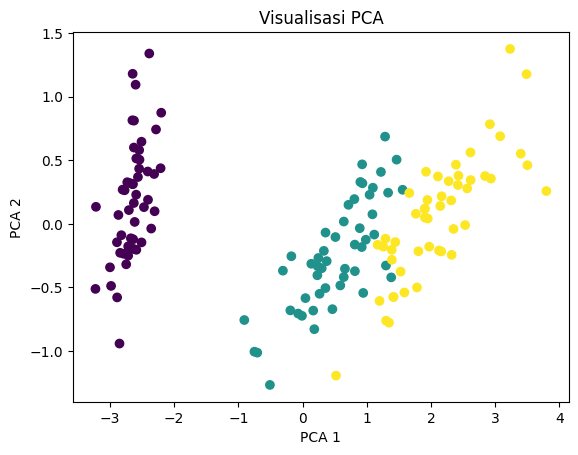

In [5]:
import matplotlib.pyplot as plt

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Visualisasi PCA")

plt.show()

## 3.6 LDA

LDA atau Linear Discriminant Analysis dapat digunakan untuk melakukan dimensionality reduction dengan mempertimbangkan kelas data.

Perbedaan sederhananya:

PCA
→ berfokus pada variasi data.

LDA
→ berfokus pada pemisahan antar kelas.

Karena LDA menggunakan informasi kelas, maka LDA membutuhkan X dan y.

In [6]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)

X_lda = lda.fit_transform(X, y)

print("Ukuran data:", X_lda.shape)

Ukuran data: (150, 2)


## 3.7 t-SNE

t-SNE merupakan metode dimensionality reduction yang sering digunakan untuk visualisasi data berdimensi tinggi.

Tujuannya adalah membantu melihat pola atau kelompok data dalam bentuk dua dimensi.

t-SNE lebih sering digunakan untuk eksplorasi dan visualisasi dibandingkan sebagai preprocessing utama untuk model Machine Learning.

In [7]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42
)

X_tsne = tsne.fit_transform(X)

print("Ukuran data:", X_tsne.shape)

Ukuran data: (150, 2)


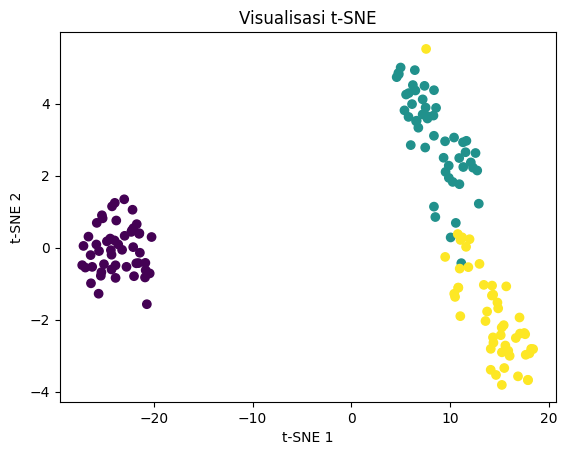

In [8]:
plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Visualisasi t-SNE")

plt.show()

## 3.8 Variance Threshold

VarianceThreshold digunakan untuk menghapus fitur yang memiliki variasi sangat rendah.

Jika suatu fitur hampir selalu memiliki nilai yang sama, fitur tersebut mungkin tidak memberikan banyak informasi untuk model.

VarianceThreshold dapat digunakan untuk menghapus fitur tersebut secara otomatis.

In [9]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.1)

X_selected = selector.fit_transform(X)

print("Sebelum:", X.shape)
print("Sesudah:", X_selected.shape)

Sebelum: (150, 4)
Sesudah: (150, 4)


## 3.9 SelectKBest

SelectKBest digunakan untuk memilih sejumlah fitur terbaik berdasarkan metode statistik tertentu.

Pada contoh ini digunakan f_classif untuk mengukur hubungan fitur dengan target kelas.

Parameter k=2 berarti hanya dua fitur terbaik yang dipilih.

In [10]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(
    score_func=f_classif,
    k=2
)

X_selected = selector.fit_transform(X, y)

print("Sebelum:", X.shape)
print("Sesudah:", X_selected.shape)

Sebelum: (150, 4)
Sesudah: (150, 2)


## 3.10 Perbedaan Metode

PCA
→ Membuat komponen baru berdasarkan variasi data.

LDA
→ Membuat komponen baru dengan mempertimbangkan kelas.

t-SNE
→ Digunakan terutama untuk visualisasi data.

VarianceThreshold
→ Menghapus fitur yang memiliki variasi rendah.

SelectKBest
→ Memilih fitur terbaik dari fitur asli.

Perbedaan penting:

PCA dan LDA menghasilkan komponen baru.

VarianceThreshold dan SelectKBest memilih atau menghapus fitur yang sudah ada.

## 3.11 Kesimpulan Bab 3

Dimensionality Reduction digunakan untuk mengurangi jumlah fitur dalam dataset.

PCA
→ Mengurangi dimensi berdasarkan variasi data.

LDA
→ Mengurangi dimensi dengan mempertimbangkan kelas.

t-SNE
→ Membantu visualisasi data berdimensi tinggi.

VarianceThreshold
→ Menghapus fitur dengan variasi rendah.

SelectKBest
→ Memilih fitur terbaik.

Tujuan akhirnya adalah membuat data lebih sederhana tanpa kehilangan terlalu banyak informasi penting.